In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Synthetic dataset
# ---------------------------

def generate_single_index(n=10000, d=100):
    w = torch.randn(d)
    X = torch.randn(n, d)

    z = X @ w
    y = torch.sin(z)

    return X, y.unsqueeze(1)

# harder function (higher intrinsic dimension)
def generate_multi_index(n=10000, d=100, k=10):
    W = torch.randn(d, k)
    X = torch.randn(n, d)

    z = X @ W
    y = torch.sum(torch.sin(z), dim=1)

    return X, y.unsqueeze(1)


# ---------------------------
# Model
# ---------------------------

class Net(nn.Module):
    def __init__(self, d):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d, 512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,1)
        )

    def forward(self,x):
        return self.net(x)


# ---------------------------
# Training
# ---------------------------

def train_epoch(model, loader, opt):

    loss_fn = nn.MSELoss()
    model.train()

    for x,y in loader:

        x = x.to(device)
        y = y.to(device)

        opt.zero_grad()

        out = model(x)
        loss = loss_fn(out,y)

        loss.backward()
        opt.step()


def train_model(model, loader, epochs=10):

    opt = optim.Adam(model.parameters(), lr=1e-3)

    for _ in range(epochs):
        train_epoch(model, loader, opt)


# ---------------------------
# Evaluation
# ---------------------------

def evaluate(model, loader):

    loss_fn = nn.MSELoss()
    model.eval()

    total = 0
    count = 0

    with torch.no_grad():

        for x,y in loader:

            x = x.to(device)
            y = y.to(device)

            out = model(x)
            loss = loss_fn(out,y)

            total += loss.item()*len(x)
            count += len(x)

    return total/count


# ---------------------------
# Pruning
# ---------------------------

def prune_model(model, sparsity):

    # collect all weights
    weights = torch.cat([
        p.data.view(-1).abs()
        for p in model.parameters()
        if len(p.data.shape) > 1
    ])

    threshold = torch.quantile(weights, sparsity)

    mask = {}

    for name,p in model.named_parameters():

        if len(p.data.shape) > 1:

            m = (p.data.abs() > threshold).float()
            p.data *= m
            mask[name] = m

    return mask


def apply_mask(model, mask):

    for name,p in model.named_parameters():

        if name in mask:
            p.data *= mask[name]


# ---------------------------
# Lottery Ticket Experiment
# ---------------------------

def lottery_experiment(dataset_fn):

    epochs = 100

    X,y = dataset_fn()

    dataset = TensorDataset(X,y)
    loader = DataLoader(dataset, batch_size=128, shuffle=True,
                        num_workers=12,
                            pin_memory=True,
                            persistent_workers=True,
                            prefetch_factor=4
                        )

    d = X.shape[1]

    # initial model
    model = Net(d).to(device)
    initial_state = copy.deepcopy(model.state_dict())

    print("Training dense model...")
    train_model(model, loader, epochs=epochs)

    dense_loss = evaluate(model, loader)
    print("Dense loss:", dense_loss)

    sparsities = [0.2,0.4,0.6,0.8,0.9,0.95]

    results = []

    for s in sparsities:

        print("\nPruning:", s)

        pruned = Net(d).to(device)
        pruned.load_state_dict(initial_state)

        mask = prune_model(pruned, s)

        pruned.load_state_dict(initial_state)
        apply_mask(pruned, mask)

        train_model(pruned, loader, epochs=epochs)

        loss = evaluate(pruned, loader)

        print("Loss:", loss)

        results.append((s, loss))

    return dense_loss, results

# ---------------------------
# Run experiments
# ---------------------------

dense_single, res_single = lottery_experiment(generate_single_index)
dense_multi, res_multi = lottery_experiment(generate_multi_index)

Training dense model...
Dense loss: 0.007486812625825405

Pruning: 0.2
Loss: 0.0064547006718814375

Pruning: 0.4
Loss: 0.007224004307389259

Pruning: 0.6
Loss: 0.007044961455464363

Pruning: 0.8
Loss: 0.008763755469024182

Pruning: 0.9
Loss: 0.00485826151072979

Pruning: 0.95
Loss: 0.007950512365996837
Training dense model...
Dense loss: 0.08649945545196533

Pruning: 0.2
Loss: 0.06153403159379959

Pruning: 0.4
Loss: 0.06086606795787811

Pruning: 0.6
Loss: 0.07924599826335907

Pruning: 0.8
Loss: 0.060859473663568496

Pruning: 0.9
Loss: 0.06319486950337887

Pruning: 0.95
Loss: 0.07039536133408547


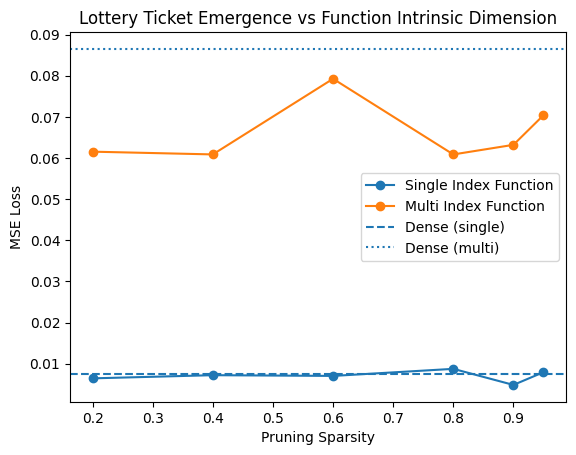

In [7]:
import matplotlib.pyplot as plt

# unpack results
s_single = [x[0] for x in res_single]
loss_single = [x[1] for x in res_single]

s_multi = [x[0] for x in res_multi]
loss_multi = [x[1] for x in res_multi]

plt.figure()

plt.plot(s_single, loss_single, marker="o", label="Single Index Function")
plt.plot(s_multi, loss_multi, marker="o", label="Multi Index Function")

plt.axhline(dense_single, linestyle="--", label="Dense (single)")
plt.axhline(dense_multi, linestyle=":", label="Dense (multi)")

plt.xlabel("Pruning Sparsity")
plt.ylabel("MSE Loss")
plt.title("Lottery Ticket Emergence vs Function Intrinsic Dimension")

plt.legend()

plt.show()

In [8]:
import numpy as np

def generate_k_index(n=10000, d=100, k=1):

    W = torch.randn(d, k)
    X = torch.randn(n, d)

    z = X @ W
    y = torch.sum(torch.sin(z), dim=1)

    return X, y.unsqueeze(1)


def run_dimension_experiment():

    dims = [1,2,5,10,20]

    results = {}

    for k in dims:

        print("\nTesting intrinsic dimension:", k)

        dataset_fn = lambda: generate_k_index(k=k)

        dense_loss, res = lottery_experiment(dataset_fn)

        best_sparsity = 0

        for s,loss in res:

            if loss <= dense_loss * 1.5:
                best_sparsity = s

        results[k] = best_sparsity

    return results



def run_dimension_experiment_repeated(repeats=5):

    dims = [1,2,5,10,20]

    results = {k: [] for k in dims}

    for r in range(repeats):

        print("\n========== RUN", r+1, "==========")

        for k in dims:

            print("Intrinsic dimension:", k)

            dataset_fn = lambda: generate_k_index(k=k)

            dense_loss, res = lottery_experiment(dataset_fn)

            best_sparsity = 0

            for s,loss in res:

                if loss <= dense_loss * 1.5:
                    best_sparsity = s

            results[k].append(best_sparsity)

    means = []
    stds = []

    for k in dims:

        vals = results[k]
        means.append(np.mean(vals))
        stds.append(np.std(vals))

    return dims, means, stds, results


dims, mean_sparsity, std_sparsity, raw_results = run_dimension_experiment_repeated(repeats=5)


========== RUN 1 ==========
Intrinsic dimension: 1
Training dense model...
Dense loss: 0.008964543785899878

Pruning: 0.2
Loss: 0.006061738184094429

Pruning: 0.4
Loss: 0.006346766751259565

Pruning: 0.6
Loss: 0.006466511055827141

Pruning: 0.8
Loss: 0.00720405984595418

Pruning: 0.9
Loss: 0.009466069702804088

Pruning: 0.95
Loss: 0.007031262826919555
Intrinsic dimension: 2
Training dense model...
Dense loss: 0.011078944279253483

Pruning: 0.2
Loss: 0.01400527791082859

Pruning: 0.4
Loss: 0.013576508951187134

Pruning: 0.6
Loss: 0.016150608457624914

Pruning: 0.8
Loss: 0.0162913238465786

Pruning: 0.9
Loss: 0.015637629315257074

Pruning: 0.95
Loss: 1.0111149229049683
Intrinsic dimension: 5
Training dense model...
Dense loss: 0.026829905274510384

Pruning: 0.2
Loss: 0.02757128023505211

Pruning: 0.4
Loss: 0.03675667293965817

Pruning: 0.6
Loss: 0.021595289528369904

Pruning: 0.8
Loss: 0.029965718588232992

Pruning: 0.9
Loss: 0.045958373153209685

Pruning: 0.95
Loss: 0.05242088446617126

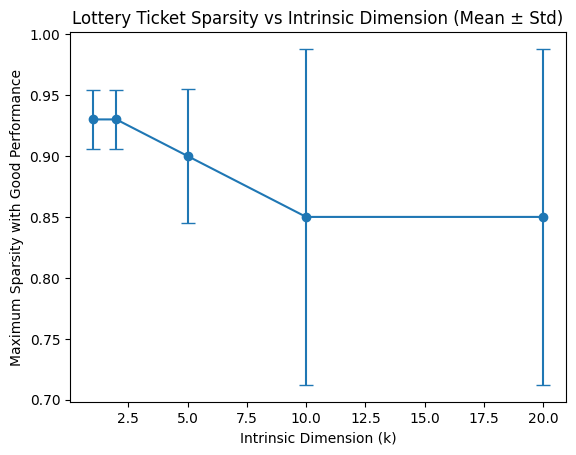

In [9]:
plt.figure()

plt.errorbar(
    dims,
    mean_sparsity,
    yerr=std_sparsity,
    marker="o",
    capsize=5
)

plt.xlabel("Intrinsic Dimension (k)")
plt.ylabel("Maximum Sparsity with Good Performance")

plt.title("Lottery Ticket Sparsity vs Intrinsic Dimension (Mean ± Std)")

plt.show()

In [10]:
import pickle

with open("dimension_experiment_results.pkl", "wb") as f:
    pickle.dump({
        "dims": dims,
        "mean_sparsity": mean_sparsity,
        "std_sparsity": std_sparsity,
        "raw_results": raw_results
    }, f)